# Lab 5: Visualization and Mini-EDA

## Objective

The objective of this lab is to reveal and communicate structure in the
clean dataset using clear and informative visualizations.

Tasks performed:
1. Create a labeled histogram and boxplot for a numerical column.
2. Create a scatter plot of two related variables with a one-line caption.
3. Create a correlation heatmap using Seaborn.
4. Perform a quick end-to-end mini-EDA and write three one-line observations.

### Task 1: Histogram and Boxplot

#### Step 1.1: Import Required Libraries

The required libraries are imported for data manipulation and visualization.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 1.2: Load the Cleaned Dataset

The cleaned Wine Quality dataset is loaded into a Pandas DataFrame for
visualization and exploratory analysis.

In [5]:
df = pd.read_csv("data/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


#### Step 1.3: Select the Numerical Column

The `alcohol` column is selected for visualization because it is a continuous
numerical variable.

In [6]:
alcohol = df["alcohol"]

alcohol.head()

0    9.4
1    9.8
2    9.8
3    9.8
4    9.4
Name: alcohol, dtype: float64

#### Step 1.4: Create Histogram

A histogram is used to visualize the distribution of alcohol content.

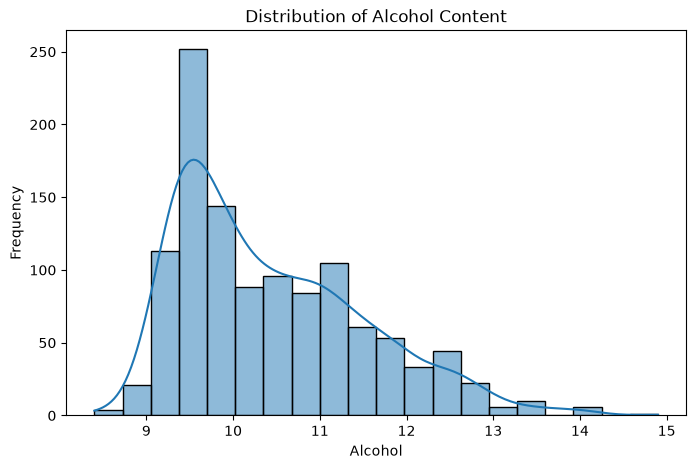

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(alcohol, bins=20, kde=True)

plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

#### Observation: Where does most of the alcohol content cluster?

Most wines fall between 9% and 11% alcohol. The distribution is right-skewed,
with a smaller number of wines reaching notably higher alcohol content
(up to ~15%), which pulls the tail out to the right.

#### Step 1.5: Create Boxplot

A boxplot is used to visualize the spread of alcohol content and identify
potential outliers.

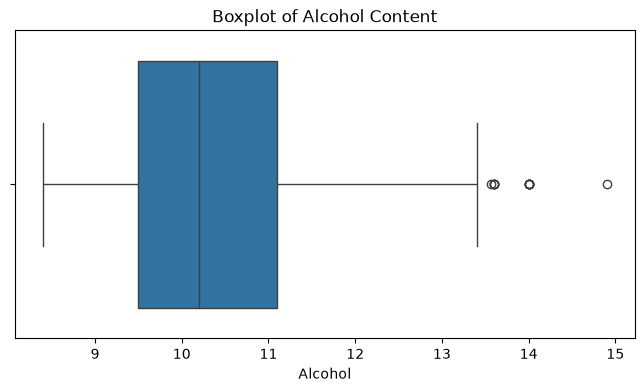

In [9]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=alcohol)

plt.title("Boxplot of Alcohol Content")
plt.xlabel("Alcohol")
plt.show()

#### Observation: How spread out is alcohol content, and are there outliers?

The median alcohol content sits around 10.2%, with the middle 50% of wines
falling roughly between 9.5% and 11.1%. Several points beyond the upper
whisker indicate a handful of unusually high-alcohol wines.

### Task 2: Scatter Plot

#### Step 2.1: Create Scatter Plot

A scatter plot is used to visualize the relationship between two numerical
variables.

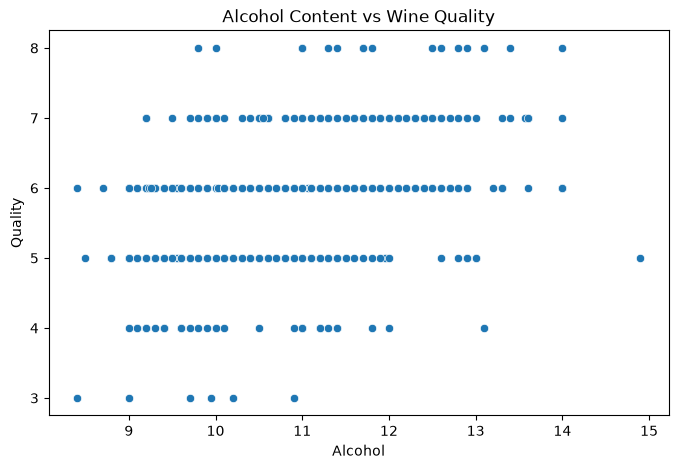

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="alcohol", y="quality")

plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

#### Caption: Higher alcohol content is loosely associated with higher wine quality scores, though the relationship is noisy rather than tightly linear.

### Task 3: Correlation Heatmap

#### Step 3.1: Create Correlation Matrix

The correlation matrix is calculated to examine relationships between
numerical variables.

In [16]:
correlation_matrix = df.select_dtypes(include="number").corr()
correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


#### Step 3.2: Create Correlation Heatmap

A heatmap is used to visually represent the strength and direction of
correlations between numerical variables.

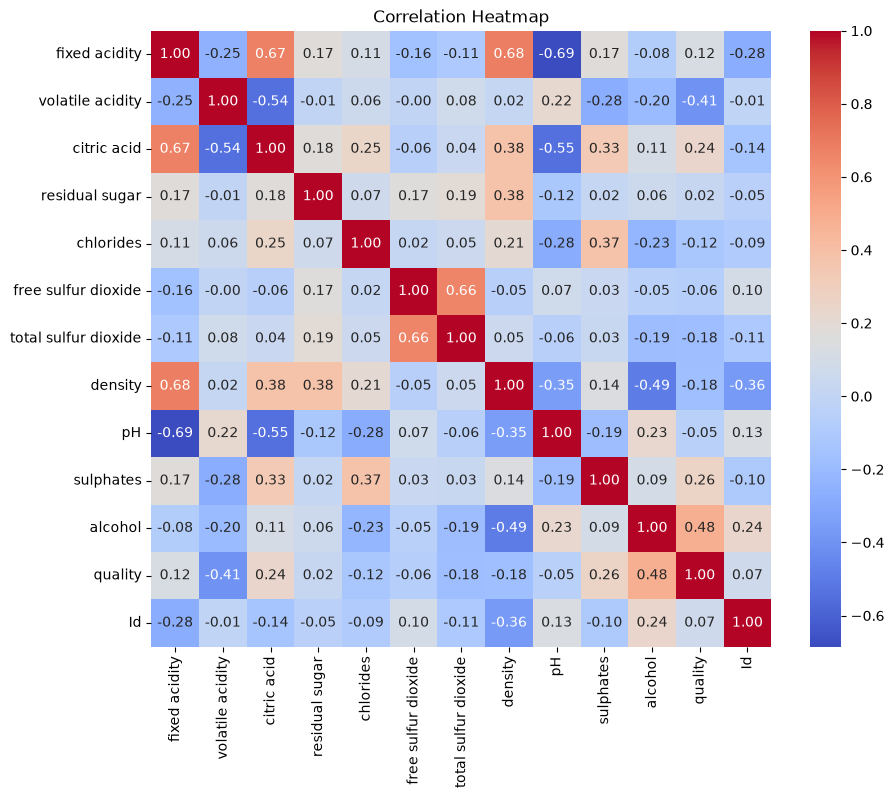

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

#### Observation: Which features move together, and which are linked to quality?

Alcohol shows the strongest positive correlation with quality (r ≈ 0.48),
while volatile acidity shows the strongest negative correlation (r ≈ -0.41).
Fixed acidity, citric acid, and density are also tightly correlated with
each other, suggesting some redundancy among the acidity-related features.

### Task 4: Mini-EDA

#### Step 4.1: Quick Dataset Overview

A quick overview of the dataset is performed to understand its structure,
dimensions, and numerical summary statistics.

In [18]:
print("Shape:", df.shape)

df.info()

Shape: (1143, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


#### Step 4.2: Summary Statistics

Summary statistics are used to understand the central tendency and spread of
the numerical variables.

In [19]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


#### Step 4.3: Check Missing Values and Duplicates

The dataset is checked for missing values and duplicate records to assess
data completeness and consistency.

In [21]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Duplicate rows: 0


## Overall Observation

- The histogram and boxplot provided insights into the distribution, spread,
  and potential outliers in the alcohol content.

- The scatter plot helped visualize the relationship between alcohol content
  and wine quality.

- The correlation heatmap showed the strength and direction of relationships
  among the numerical variables.

- Overall, the visualizations and mini-EDA helped identify important patterns
  and provided a clear understanding of the dataset.